# Libraries

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

# Data

In [46]:
splits = {'train': 'train.csv', 'validation': 'valid.csv', 'test': 'test.csv'}
train_df = pd.read_csv("hf://datasets/papluca/language-identification/" + splits["train"])

In [47]:
train_df.head()

,labels,text
0,pt,"os chefes de defesa da estónia, letónia, lituâ..."
1,bg,размерът на хоризонталната мрежа може да бъде ...
2,zh,很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把...
3,th,สำหรับ ของเก่า ที่ จริงจัง ลอง honeychurch ...
4,ru,Он увеличил давление .


In [48]:
train_df['labels'].unique(),len(train_df['labels'].unique())

(array(['pt', 'bg', 'zh', 'th', 'ru', 'pl', 'ur', 'sw', 'tr', 'es', 'ar',
        'it', 'hi', 'de', 'el', 'nl', 'fr', 'vi', 'en', 'ja'], dtype=object),
 20)

In [49]:
len(train_df)

70000

# EDA

In [50]:
print(train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   labels  70000 non-null  object
 1   text    70000 non-null  object
dtypes: object(2)
memory usage: 1.1+ MB
None


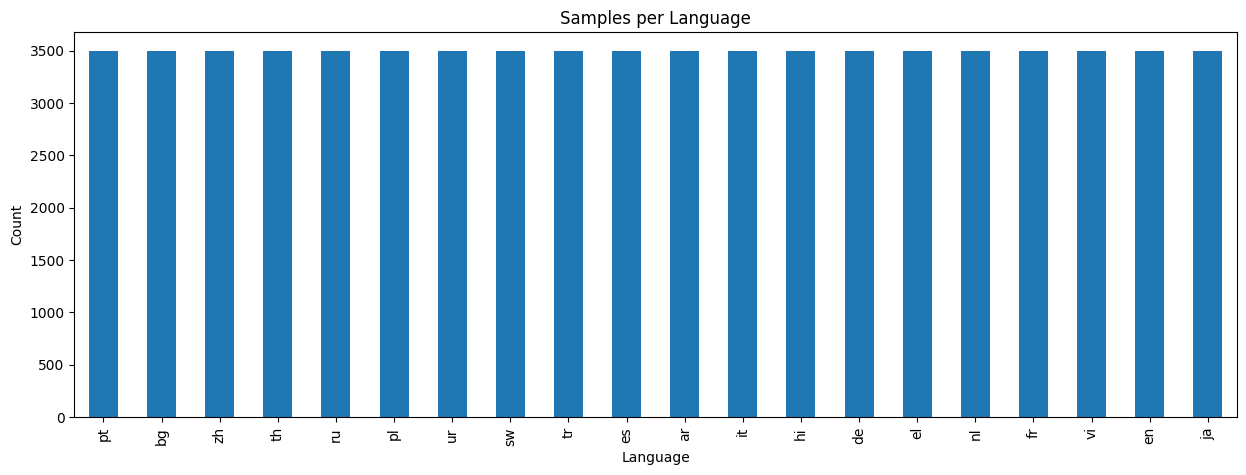

In [51]:
lang_counts = train_df["labels"].value_counts()

lang_counts.plot(kind='bar', figsize=(15,5))
plt.title("Samples per Language")
plt.xlabel("Language")
plt.ylabel("Count")
plt.show()

In [52]:
train_df["char_length"] = train_df["text"].str.len()

print(train_df["char_length"].describe())

count    70000.000000
mean       110.861414
std        103.106240
min          2.000000
25%         47.000000
50%         82.000000
75%        143.000000
max       2422.000000
Name: char_length, dtype: float64


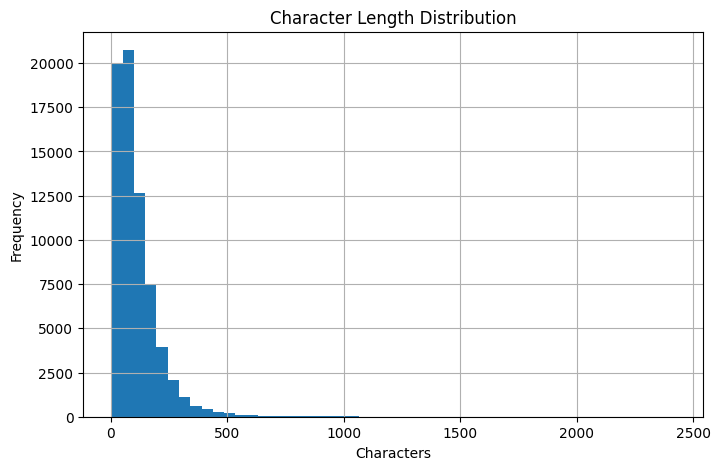

In [53]:
plt.figure(figsize=(8,5))

train_df["char_length"].hist(bins=50)

plt.title("Character Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

In [54]:
print(train_df.isnull().sum())

labels         0
text           0
char_length    0
dtype: int64


In [55]:
duplicates = train_df["text"].duplicated().sum()

print("Duplicate texts:", duplicates)

Duplicate texts: 1022


In [56]:
train_df = train_df.drop_duplicates(subset=['text'])

In [57]:
X_train = train_df["text"]
y_train = train_df["labels"]

# Train

In [58]:
model_sv = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            analyzer="char",
            ngram_range=(2, 5),
            lowercase=True,
            min_df=2
        )
    ),
    (
        "classifier",
        LinearSVC()
    )
])

model_sv.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(analyzer='char', max_features=100000, min_df=2,
                                 ngram_range=(2, 5))),
                ('classifier', LinearSVC())])

# Evaluate

In [59]:
valid_df = pd.read_csv("hf://datasets/papluca/language-identification/" + splits["validation"])

X_valid = valid_df["text"]
y_valid = valid_df["labels"]

accuracy = model_sv.score(X_valid, y_valid)

print(f"Validation Accuracy: {accuracy:.4f}")

Validation Accuracy: 0.9952


# Predict

In [60]:
samples = [
    "Hello, how are you?",
    "Bonjour tout le monde",
    "Hola amigos",
    "مرحبا كيف حالك"
]

predictions = model_sv.predict(samples)

for text, lang in zip(samples, predictions):
    print(f"{lang}: {text}")

en: Hello, how are you?
fr: Bonjour tout le monde
it: Hola amigos
ar: مرحبا كيف حالك


In [61]:
text = ["hello my name is mazen"]
print(model_sv.predict(text))

['sw']


In [62]:
tests = [
    "hello",
    "hello my name is",
    "my name is john",
    "my name is mazen",
    "hello my name is mazen"
]

for t in tests:
    print(t, "->", model_sv.predict([t])[0])

hello -> it
hello my name is -> sw
my name is john -> sw
my name is mazen -> sw
hello my name is mazen -> sw


In [63]:
from sklearn.naive_bayes import MultinomialNB
model_nb = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            analyzer="char",
            ngram_range=(2, 5),
            min_df=2,
            max_features=100_000
        )
    ),
    ("clf", MultinomialNB())
])

In [64]:
model_nb.fit(X_train, y_train)
accuracy_nb = model_nb.score(X_valid, y_valid)

print(f"Validation Accuracy: {accuracy_nb:.4f}")

Validation Accuracy: 0.9933


In [66]:
tests = [
    "hello",
    "hello my name is",
    "my name is john",
    "my name is mazen",
    "hello my name is mazen"
]

for t in tests:
    print(t, "->", model_nb.predict([t])[0])

hello -> it
hello my name is -> en
my name is john -> en
my name is mazen -> en
hello my name is mazen -> en


In [68]:
model_nb.predict(["I'm mazen"])

array(['en'], dtype='<U2')

In [69]:
import joblib

joblib.dump(model_nb, "language_detector_v1.1.joblib")

['language_detector_v1.1.joblib']